# Perfilado de datasets mineria
- Juan Pablo Mosquera
- David Zahid Riveros
- Oscar Manuel Contreras Gacha
- Anderson David Arenas Gutierrez

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 110)
rng = np.random.default_rng(2026)
print("pandas", pd.__version__)

#FIFA

In [2]:
df = pd.read_csv('fifa_eda_stats.csv')

In [3]:
"""Limpieza de valores de dinero"""
def convert_value_to_numeric(value_str):
    if pd.isna(value_str) or not isinstance(value_str, str):
        return None
    value_str = value_str.replace('€', '').strip()
    if 'M' in value_str:
        return float(value_str.replace('M', '')) * 1_000_000
    elif 'K' in value_str:
        return float(value_str.replace('K', '')) * 1_000
    elif value_str == '0':
        return 0.0
    else:
        try:
            return float(value_str)
        except ValueError:
            return None
df['Value'] = df['Value'].apply(convert_value_to_numeric)
df['Wage'] = df['Wage'].apply(convert_value_to_numeric)
df['Release Clause'] = df['Release Clause'].apply(convert_value_to_numeric)

In [4]:
print(df["Value"].value_counts(normalize=True).round(3))

Value
1100000.0     0.024
375000.0      0.020
425000.0      0.019
325000.0      0.019
450000.0      0.019
              ...  
63000000.0    0.000
51500000.0    0.000
53500000.0    0.000
58000000.0    0.000
81000000.0    0.000
Name: proportion, Length: 217, dtype: float64


In [5]:
def perfilar(df):
    filas = []
    for col in df.columns:
        s = df[col]
        fila = {
            "columna":   col,
            "tipo":      str(s.dtype),
            "distintos": s.nunique(),
            "faltan_%":  round(s.isna().mean() * 100, 1),
            "moda":      s.mode().iloc[0] if not s.mode().empty else None,
        }
        if pd.api.types.is_numeric_dtype(s):
            fila["min"]     = round(s.min(), 2)
            fila["mediana"] = round(s.median(), 2)
            fila["media"]   = round(s.mean(), 2)
            fila["max"]     = round(s.max(), 2)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("columna")

perfilar(df)


,tipo,distintos,faltan_%,moda,min,mediana,media,max
columna,,,,,,,,
ID,int64,18207,0.0,16,16.0,221759.0,214298.34,246620.0
Name,object,17194,0.0,J. Rodríguez,NaN,NaN,NaN,NaN
Age,int64,29,0.0,21,16.0,25.0,25.12,45.0
Nationality,object,164,0.0,England,NaN,NaN,NaN,NaN
Overall,int64,48,0.0,66,46.0,66.0,66.24,94.0
Potential,int64,47,0.0,70,48.0,71.0,71.31,95.0
Club,object,651,1.3,AS Monaco,NaN,NaN,NaN,NaN
Value,float64,217,0.0,1100000.0,0.0,675000.0,2410695.89,118500000.0
Wage,float64,144,0.0,1000.0,0.0,3000.0,9731.31,565000.0


1. Corra `perfilar()` y pegue la salida.

<div id="df-812bf6ae-a487-4752-ad77-2c6b21f068fc" class="colab-df-container">
    <div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>tipo</th>
      <th>distintos</th>
      <th>faltan_%</th>
      <th>moda</th>
      <th>min</th>
      <th>mediana</th>
      <th>media</th>
      <th>max</th>
    </tr>
    <tr>
      <th>columna</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>ID</th>
      <td>int64</td>
      <td>18207</td>
      <td>0.0</td>
      <td>16</td>
      <td>16.0</td>
      <td>221759.0</td>
      <td>214298.34</td>
      <td>246620.0</td>
    </tr>
    <tr>
      <th>Name</th>
      <td>object</td>
      <td>17194</td>
      <td>0.0</td>
      <td>J. Rodríguez</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Age</th>
      <td>int64</td>
      <td>29</td>
      <td>0.0</td>
      <td>21</td>
      <td>16.0</td>
      <td>25.0</td>
      <td>25.12</td>
      <td>45.0</td>
    </tr>
    <tr>
      <th>Nationality</th>
      <td>object</td>
      <td>164</td>
      <td>0.0</td>
      <td>England</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Overall</th>
      <td>int64</td>
      <td>48</td>
      <td>0.0</td>
      <td>66</td>
      <td>46.0</td>
      <td>66.0</td>
      <td>66.24</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Potential</th>
      <td>int64</td>
      <td>47</td>
      <td>0.0</td>
      <td>70</td>
      <td>48.0</td>
      <td>71.0</td>
      <td>71.31</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Club</th>
      <td>object</td>
      <td>651</td>
      <td>1.3</td>
      <td>AS Monaco</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Value</th>
      <td>object</td>
      <td>217</td>
      <td>0.0</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Wage</th>
      <td>object</td>
      <td>144</td>
      <td>0.0</td>
      <td>€1K</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Preferred Foot</th>
      <td>object</td>
      <td>2</td>
      <td>0.3</td>
      <td>Right</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>International Reputation</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.11</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Weak Foot</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>3.0</td>
      <td>1.0</td>
      <td>3.0</td>
      <td>2.95</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Skill Moves</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>2.0</td>
      <td>1.0</td>
      <td>2.0</td>
      <td>2.36</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Work Rate</th>
      <td>object</td>
      <td>9</td>
      <td>0.3</td>
      <td>Medium/ Medium</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Body Type</th>
      <td>object</td>
      <td>10</td>
      <td>0.3</td>
      <td>Normal</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Position</th>
      <td>object</td>
      <td>27</td>
      <td>0.3</td>
      <td>ST</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Jersey Number</th>
      <td>float64</td>
      <td>99</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>17.0</td>
      <td>19.55</td>
      <td>99.0</td>
    </tr>
    <tr>
      <th>Joined</th>
      <td>object</td>
      <td>1736</td>
      <td>8.5</td>
      <td>Jul 1, 2018</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Loaned From</th>
      <td>object</td>
      <td>341</td>
      <td>93.1</td>
      <td>Atalanta</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Contract Valid Until</th>
      <td>object</td>
      <td>36</td>
      <td>1.6</td>
      <td>2019</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Height</th>
      <td>object</td>
      <td>21</td>
      <td>0.3</td>
      <td>6'0</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Weight</th>
      <td>object</td>
      <td>57</td>
      <td>0.3</td>
      <td>165lbs</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Crossing</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>5.0</td>
      <td>54.0</td>
      <td>49.73</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Finishing</th>
      <td>float64</td>
      <td>93</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>49.0</td>
      <td>45.55</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>HeadingAccuracy</th>
      <td>float64</td>
      <td>91</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>4.0</td>
      <td>56.0</td>
      <td>52.30</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>ShortPassing</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>7.0</td>
      <td>62.0</td>
      <td>58.69</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Volleys</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>49.0</td>
      <td>4.0</td>
      <td>44.0</td>
      <td>42.91</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>Dribbling</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>4.0</td>
      <td>61.0</td>
      <td>55.37</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>Curve</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>6.0</td>
      <td>48.0</td>
      <td>47.17</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>FKAccuracy</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>42.0</td>
      <td>3.0</td>
      <td>41.0</td>
      <td>42.86</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>LongPassing</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>9.0</td>
      <td>56.0</td>
      <td>52.71</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>BallControl</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>5.0</td>
      <td>63.0</td>
      <td>58.37</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Acceleration</th>
      <td>float64</td>
      <td>86</td>
      <td>0.3</td>
      <td>69.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.61</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>SprintSpeed</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.73</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Agility</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>14.0</td>
      <td>66.0</td>
      <td>63.50</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Reactions</th>
      <td>float64</td>
      <td>68</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>21.0</td>
      <td>62.0</td>
      <td>61.84</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Balance</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>16.0</td>
      <td>66.0</td>
      <td>63.97</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>ShotPower</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>2.0</td>
      <td>59.0</td>
      <td>55.46</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Jumping</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>70.0</td>
      <td>15.0</td>
      <td>66.0</td>
      <td>65.09</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Stamina</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>66.0</td>
      <td>63.22</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Strength</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>17.0</td>
      <td>67.0</td>
      <td>65.31</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>LongShots</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>59.0</td>
      <td>3.0</td>
      <td>51.0</td>
      <td>47.11</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Aggression</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>11.0</td>
      <td>59.0</td>
      <td>55.87</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Interceptions</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>46.70</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Positioning</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>49.96</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Vision</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>10.0</td>
      <td>55.0</td>
      <td>53.40</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Penalties</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>45.0</td>
      <td>5.0</td>
      <td>49.0</td>
      <td>48.55</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Composure</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>60.0</td>
      <td>58.65</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Marking</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>53.0</td>
      <td>47.28</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>StandingTackle</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>66.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>47.70</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>SlidingTackle</th>
      <td>float64</td>
      <td>88</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>45.66</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKDiving</th>
      <td>float64</td>
      <td>71</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.62</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKHandling</th>
      <td>float64</td>
      <td>70</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>GKKicking</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>12.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.23</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKPositioning</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKReflexes</th>
      <td>float64</td>
      <td>76</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.71</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Release Clause</th>
      <td>object</td>
      <td>1244</td>
      <td>8.6</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
  </tbody>
</table>
</div>
    <div class="colab-df-buttons">
      
  <div class="colab-df-container">
    <button class="colab-df-convert" onclick="convertToInteractive('df-812bf6ae-a487-4752-ad77-2c6b21f068fc')"
            title="Convert this dataframe to an interactive table."
            style="display:none;">
      
  <svg xmlns="http://www.w3.org/2000/svg" height="24px" viewBox="0 -960 960 960">
    <path d="M120-120v-720h720v720H120Zm60-500h600v-160H180v160Zm220 220h160v-160H400v160Zm0 220h160v-160H400v160ZM180-400h160v-160H180v160Zm440 0h160v-160H620v160ZM180-180h160v-160H180v160Zm440 0h160v-160H620v160Z"/>
  </svg>
    </button>
    
  <style>
    .colab-df-container {
      display:flex;
      gap: 12px;
    }

    .colab-df-convert {
      background-color: #E8F0FE;
      border: none;
      border-radius: 50%;
      cursor: pointer;
      display: none;
      fill: #1967D2;
      height: 32px;
      padding: 0 0 0 0;
      width: 32px;
    }

    .colab-df-convert:hover {
      background-color: #E2EBFA;
      box-shadow: 0px 1px 2px rgba(60, 64, 67, 0.3), 0px 1px 3px 1px rgba(60, 64, 67, 0.15);
      fill: #174EA6;
    }

    .colab-df-buttons div {
      margin-bottom: 4px;
    }

    [theme=dark] .colab-df-convert {
      background-color: #3B4455;
      fill: #D2E3FC;
    }

    [theme=dark] .colab-df-convert:hover {
      background-color: #434B5C;
      box-shadow: 0px 1px 3px 1px rgba(0, 0, 0, 0.15);
      filter: drop-shadow(0px 1px 2px rgba(0, 0, 0, 0.3));
      fill: #FFFFFF;
    }
  </style>
  </div>
  
  </div>

### Tres problemas encontrados y su solución

* **`Loaned From` con 93.1% de datos nulos:**  
  La gran mayoría de jugadores no están cedidos a préstamo, lo que genera una columna desierta de casi solo faltantes.  
  * **Solución:** Eliminar la columna por falta de varianza o convertirla en una bandera binaria `is_loaned` (1 si tiene club de origen, 0 si es `NaN`).

* **Valores numéricos guardados como texto (`Height` y `Weight`):**  
  Tienen formato de cadena tipo `6'0` y `165lbs`, lo que impide su análisis estadístico y cálculo de correlación directa.  
  * **Solución:** Aplicar una función de transformación en Pandas para convertir `Height` a centímetros y `Weight` a kilogramos (o libras numéricas) y castearlas a tipo `float64`.

* **Nulos masivos en cláusula de rescisión (`Release Clause` con 8.6% de faltantes):**  
  Existen 1,564 jugadores sin cláusula asignada en la base de datos.  
  * **Solución:** Imputar los faltantes calculando una estimación basada en la relación proporcional entre `Value` y `Overall`, o asignar 0 si el contrato no contempla dicha cláusula.

---

### Columna objetivo y su reparto (`Value`)

Al ser **`Value`** una variable continua económica (target de regresión), el método `value_counts(normalize=True)` se utiliza para observar la concentración del mercado o agrupar por rangos. Su reparto estadístico directo muestra:

* **Mínimo:** €0.0
* **Mediana:** €675,000.0
* **Media:** €2,410,695.89
* **Máximo:** €118,500,000.0

*(El reparto de `Value` presenta un marcado sesgo positivo a la derecha [right-skewed], donde más del 50% de los jugadores tiene un valor de mercado inferior a €675,000, mientras que una élite de superestrellas eleva la media a €2.4M y alcanza un pico de €118.5M).*

---

### ¿Este archivo aguanta el semestre?

**Sí, aguanta perfectamente el semestre**, porque cuenta con un volumen masivo de datos (18,207 registros), más de 80 variables con gran diversidad de tipos (métricas físicas, habilidades técnicas de 0 a 100, salarios y valor comercial) y múltiples desafíos de limpieza (nulos masivos, parseo de cadenas y transformaciones financieras) suficientes para todas las entregas de minería.

### Solución al Problema 1: Columna `Loaned From` con valores nulos

Se crea una nueva columna `is_loaned` que indica si el jugador está cedido (1) o no (0). Posteriormente, se elimina la columna original `Loaned From`.

In [6]:
# Crear la columna binaria 'is_loaned': 1 si el jugador está cedido (no es NaN en 'Loaned From'), 0 en caso contrario.
df['is_loaned'] = df['Loaned From'].notna().astype(int)

# Eliminar la columna original 'Loaned From' ya que la nueva columna captura la información relevante.
df = df.drop(columns=['Loaned From'])

# Mostrar las primeras filas del DataFrame con la nueva columna y la columna eliminada
display(df[['Name', 'Club', 'is_loaned']].head())

# Verificar el tipo de datos y la ausencia de la columna original
print(df[['is_loaned']].info())

,Name,Club,is_loaned
0,L. Messi,FC Barcelona,0
1,Cristiano Ronaldo,Juventus,0
2,Neymar Jr,Paris Saint-Germain,0
3,De Gea,Manchester United,0
4,K. De Bruyne,Manchester City,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   is_loaned  18207 non-null  int64
dtypes: int64(1)
memory usage: 142.4 KB
None


### Solución al Problema 2: Valores numéricos guardados como texto (`Height` y `Weight`)

Se convierten las columnas `Height` y `Weight` de formato texto a numérico. Para `Height`, se convierte de pies y pulgadas a centímetros. Para `Weight`, se elimina la unidad 'lbs' y se convierte a float.

In [7]:
# Función para convertir altura de pies'pulgadas a centímetros
def convert_height_to_cm(height_str):
    if pd.isna(height_str) or not isinstance(height_str, str):
        return None
    try:
        feet, inches = map(int, height_str.replace('"', '').split("'"))
        return (feet * 30.48) + (inches * 2.54)
    except ValueError:
        return None

# Función para convertir peso de 'Xlbs' a un valor numérico en libras
def convert_weight_to_lbs(weight_str):
    if pd.isna(weight_str) or not isinstance(weight_str, str):
        return None
    try:
        return float(weight_str.replace('lbs', ''))
    except ValueError:
        return None

# Aplicar las funciones de conversión a las columnas 'Height' y 'Weight'
df['Height_cm'] = df['Height'].apply(convert_height_to_cm)
df['Weight_lbs'] = df['Weight'].apply(convert_weight_to_lbs)

# Eliminar las columnas originales 'Height' y 'Weight' si ya no son necesarias
df = df.drop(columns=['Height', 'Weight'])

# Mostrar las primeras filas del DataFrame con las nuevas columnas y las columnas eliminadas
display(df[['Name', 'Height_cm', 'Weight_lbs']].head())

# Verificar el tipo de datos de las nuevas columnas
print(df[['Height_cm', 'Weight_lbs']].info())

,Name,Height_cm,Weight_lbs
0,L. Messi,170.18,159.0
1,Cristiano Ronaldo,187.96,183.0
2,Neymar Jr,175.26,150.0
3,De Gea,193.04,168.0
4,K. De Bruyne,180.34,154.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Height_cm   18159 non-null  float64
 1   Weight_lbs  18159 non-null  float64
dtypes: float64(2)
memory usage: 284.6 KB
None


### Solución al Problema 3: Nulos en la columna `Release Clause`

Se imputan los valores nulos en la columna `Release Clause` con 0, asumiendo que un valor nulo significa que no hay cláusula de rescisión para ese jugador.

In [8]:
# Imputar los valores nulos en 'Release Clause' con 0
df['Release Clause'] = df['Release Clause'].fillna(0)

# Verificar el número de valores nulos después de la imputación
print(f"Valores nulos en 'Release Clause' después de la imputación: {df['Release Clause'].isnull().sum()}")

# Mostrar una descripción estadística de la columna 'Release Clause' para verificar los cambios
display(df[['Name', 'Club', 'Value', 'Release Clause']].head())

# Verificar el tipo de datos de la columna 'Release Clause'
print(df[['Release Clause']].info())

Valores nulos en 'Release Clause' después de la imputación: 0


,Name,Club,Value,Release Clause
0,L. Messi,FC Barcelona,110500000.0,226500000.0
1,Cristiano Ronaldo,Juventus,77000000.0,127100000.0
2,Neymar Jr,Paris Saint-Germain,118500000.0,228100000.0
3,De Gea,Manchester United,72000000.0,138600000.0
4,K. De Bruyne,Manchester City,102000000.0,196400000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Release Clause  18207 non-null  float64
dtypes: float64(1)
memory usage: 142.4 KB
None


In [9]:
df.describe()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Weak Foot,Skill Moves,Jersey Number,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,is_loaned,Height_cm,Weight_lbs
count,18207.000000,18207.000000,18207.000000,18207.000000,1.820700e+04,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,1.820700e+04,18207.000000,18159.000000,18159.000000
mean,214298.338606,25.122206,66.238699,71.307299,2.410696e+06,9731.312133,1.113222,2.947299,2.361308,19.546096,...,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887,4.191200e+06,0.069424,181.257584,165.979129
std,29965.244204,4.669943,6.908930,6.136496,5.594933e+06,21999.290406,0.394031,0.660456,0.756164,15.947765,...,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119,1.070778e+07,0.254180,6.730145,15.593344
min,16.000000,16.000000,46.000000,48.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000,154.940000,110.000000
25%,200315.500000,21.000000,62.000000,67.000000,3.000000e+05,1000.000000,1.000000,3.000000,2.000000,8.000000,...,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000,3.920000e+05,0.000000,175.260000,154.000000
50%,221759.000000,25.000000,66.000000,71.000000,6.750000e+05,3000.000000,1.000000,3.000000,2.000000,17.000000,...,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000,1.000000e+06,0.000000,180.340000,165.000000
75%,236529.500000,28.000000,71.000000,75.000000,2.000000e+06,9000.000000,1.000000,3.000000,3.000000,26.000000,...,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000,3.000000e+06,0.000000,185.420000,176.000000
max,246620.000000,45.000000,94.000000,95.000000,1.185000e+08,565000.000000,5.000000,5.000000,5.000000,99.000000,...,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000,2.281000e+08,1.000000,205.740000,243.000000


## Normalización del Dataset

Aplicaremos diferentes técnicas de normalización a las columnas numéricas relevantes para preparar el dataset para modelos de aprendizaje automático. Los pasos se detallarán en celdas separadas con comentarios explicativos.

### 1. Normalización Min-Max Scaling

Esta técnica escala los datos a un rango fijo, generalmente entre 0 y 1. Se aplicará a las columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`) para observar su efecto.

In [13]:
# Seleccionar las columnas comunes para aplicar todos los métodos de normalización
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage']

# Crear una copia del DataFrame para Min-Max Scaling
df_minmax_scaled = df.copy()

# Inicializar el escalador Min-Max
scaler_minmax = MinMaxScaler()

# Aplicar Min-Max Scaling a las columnas seleccionadas
# Se manejan los NaN internamente por MinMaxScaler o se imputan previamente si es necesario.
# En este caso, Height_cm y Weight_lbs tienen algunos NaN que MinMaxScaler ignorará.
df_minmax_scaled[common_numerical_cols] = scaler_minmax.fit_transform(df_minmax_scaled[common_numerical_cols])

# Mostrar las primeras filas del DataFrame con las columnas normalizadas
print("DataFrame después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].head())

# Mostrar la descripción estadística de las columnas normalizadas para verificar el rango (0-1)
print("Descripción estadística después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].describe())

DataFrame después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage
0,0.517241,1.000000,0.978723,0.30,0.368421,0.932489,1.000000
1,0.586207,1.000000,0.978723,0.65,0.548872,0.649789,0.716814
2,0.344828,0.958333,0.957447,0.40,0.300752,1.000000,0.513274
3,0.379310,0.937500,0.957447,0.75,0.436090,0.607595,0.460177
4,0.379310,0.937500,0.936170,0.50,0.330827,0.860759,0.628319


Descripción estadística después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage
count,18207.000000,18207.000000,18207.000000,18159.000000,18159.000000,18207.000000,18207.000000
mean,0.314559,0.421640,0.495900,0.518063,0.420896,0.020343,0.017224
std,0.161033,0.143936,0.130564,0.132483,0.117243,0.047215,0.038937
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.172414,0.333333,0.404255,0.400000,0.330827,0.002532,0.001770
50%,0.310345,0.416667,0.489362,0.500000,0.413534,0.005696,0.005310
75%,0.413793,0.520833,0.574468,0.600000,0.496241,0.016878,0.015929
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 2. Transformación Logarítmica

Las columnas con distribuciones muy sesgadas se benefician de la transformación logarítmica para reducir la asimetría. Aplicaremos esta transformación a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`) para comparar su efecto con Min-Max Scaling.

In [14]:
import numpy as np

# Seleccionar las columnas comunes para aplicar la transformación logarítmica (las mismas que Min-Max)
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage']

# Crear una copia del DataFrame para la transformación logarítmica
df_log_transformed = df.copy()

# Antes de aplicar la transformación logarítmica, se añade 1 para manejar valores de 0
# y evitar logaritmos indefinidos (log(0)).
# Aplicar np.log1p (log(1+x)) para manejar posibles ceros en los datos.
for col in common_numerical_cols:
    # Manejar NaN antes de log transform, por ejemplo, imputar con la media o 0 si es apropiado para la columna
    # Aquí, para demostración, rellenaremos con 0 para que np.log1p(0) = 0, pero en un caso real se analizaría más
    df_log_transformed[f'{col}_log'] = np.log1p(df_log_transformed[col].fillna(0))

# Mostrar las primeras filas del DataFrame con las columnas transformadas
print("DataFrame después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].head())

# Mostrar la descripción estadística de las columnas transformadas
print("Descripción estadística después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].describe())

DataFrame después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log
0,3.465736,4.553877,4.553877,5.142716,5.075174,18.520526,13.244583
1,3.526361,4.553877,4.553877,5.241535,5.214936,18.159316,12.911645
2,3.295837,4.532599,4.543295,5.171960,5.017280,18.590424,12.577640
3,3.332205,4.521789,4.543295,5.268064,5.129899,18.092177,12.468441
4,3.332205,4.521789,4.532599,5.200374,5.043425,18.440483,12.779876


Descripción estadística después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log
count,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000
mean,3.246963,4.202908,4.277340,5.191016,5.100029,13.431882,8.166463
std,0.177829,0.103806,0.084663,0.269439,0.278335,2.117123,1.545876
min,2.833213,3.850148,3.891820,0.000000,0.000000,0.000000,0.000000
25%,3.091042,4.143135,4.219508,5.171960,5.043425,12.611541,6.908755
50%,3.258097,4.204693,4.276666,5.200374,5.111988,13.422469,8.006701
75%,3.367296,4.276666,4.330733,5.228002,5.176150,14.508658,9.105091
max,3.828641,4.553877,4.564348,5.331462,5.497168,18.590424,13.244583


### 3. Estandarización Z-score

Esta técnica transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Aplicaremos la estandarización Z-score a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`) para comparar los resultados con las otras dos normalizaciones.

In [15]:
from sklearn.preprocessing import StandardScaler

# Seleccionar las columnas comunes para aplicar Z-score Standardization (las mismas que las anteriores)
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage']

# Crear una copia del DataFrame para Z-score Standardization
df_zscore_scaled = df.copy()

# Inicializar el estandarizador Z-score
scaler_standard = StandardScaler()

# Aplicar Z-score Standardization a las columnas seleccionadas
# StandardScaler también puede manejar NaN, pero es mejor imputarlos previamente.
# Aquí, para demostración, se imputarán con la media para evitar problemas y mostrar un resultado completo.
for col in common_numerical_cols:
    df_zscore_scaled[col] = df_zscore_scaled[col].fillna(df_zscore_scaled[col].mean())

df_zscore_scaled[common_numerical_cols] = scaler_standard.fit_transform(df_zscore_scaled[common_numerical_cols])

# Mostrar las primeras filas del DataFrame con las columnas estandarizadas
print("DataFrame después de Estandarización Z-score:")
display(df_zscore_scaled[common_numerical_cols].head())

# Mostrar la descripción estadística de las columnas estandarizadas para verificar la media (~0) y la desviación estándar (~1)
print("Descripción estadística después de Estandarización Z-score:")
display(df_zscore_scaled[common_numerical_cols].describe())

DataFrame después de Estandarización Z-score:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage
0,1.258678,4.018287,3.698092,-1.648184,-0.448174,19.319674,25.240993
1,1.686961,4.018287,3.698092,0.997223,1.093019,13.331948,17.967832
2,0.187972,3.728799,3.535128,-0.892354,-1.026122,20.749578,12.740247
3,0.402113,3.584055,3.535128,1.753053,0.129773,12.438258,11.376529
4,0.402113,3.584055,3.372164,-0.136523,-0.769256,17.800400,15.694969


Descripción estadística después de Estandarización Z-score:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage
count,1.820700e+04,1.820700e+04,1.820700e+04,1.820700e+04,1.820700e+04,1.820700e+04,1.820700e+04
mean,1.623473e-16,3.246947e-16,6.993423e-16,-3.657498e-15,-1.317511e-15,-1.248826e-17,1.248826e-17
std,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00
min,-1.953441e+00,-2.929434e+00,-3.798249e+00,-3.915676e+00,-3.594778e+00,-4.308831e-01,-4.423588e-01
25%,-8.827344e-01,-6.135271e-01,-7.019345e-01,-8.923537e-01,-7.692565e-01,-3.772617e-01,-3.969015e-01
50%,-2.616929e-02,-3.455035e-02,-5.007872e-02,-1.365232e-01,-6.287612e-02,-3.102349e-01,-3.059870e-01
75%,6.162545e-01,6.891706e-01,6.017770e-01,6.193074e-01,6.435042e-01,-7.340699e-02,-3.324345e-02
max,4.256656e+00,4.018287e+00,3.861056e+00,3.642630e+00,4.946003e+00,2.074958e+01,2.524099e+01


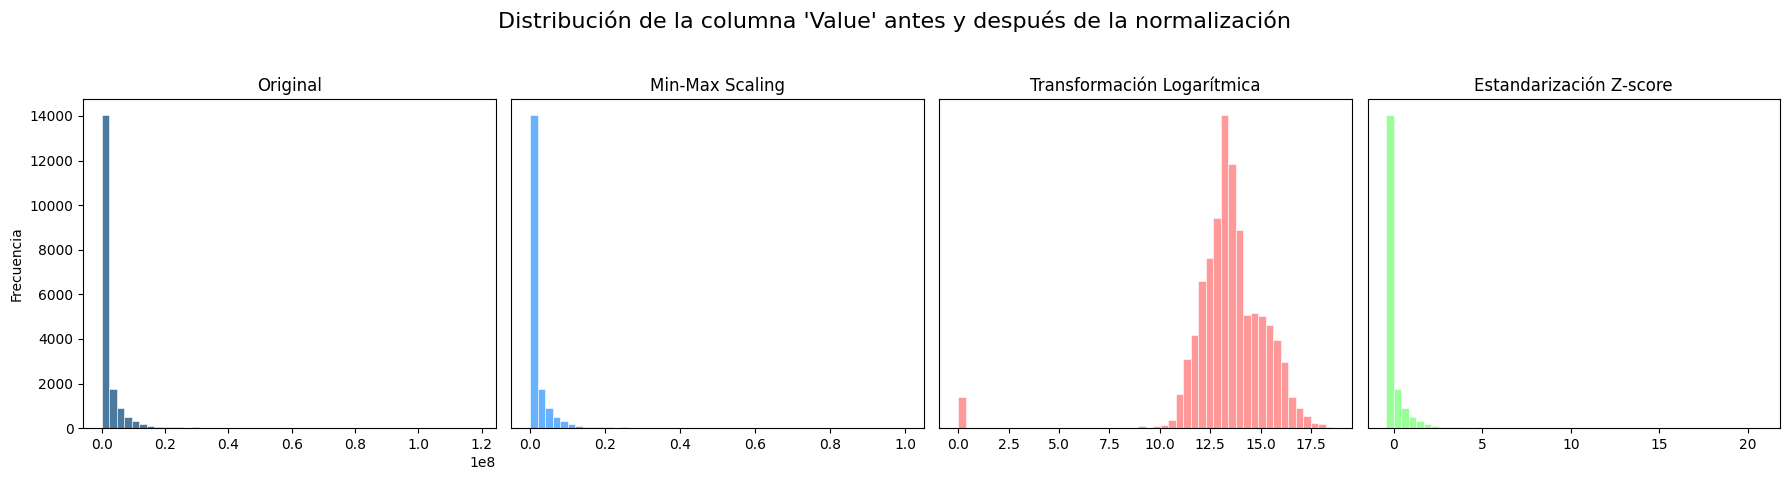

In [16]:
import matplotlib.pyplot as plt

# Seleccionamos una columna para visualizar su distribución antes y después de la normalización
column_to_plot = 'Value'

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Distribución de la columna \'{column_to_plot}\' antes y después de la normalización', fontsize=16)

# Original
ax[0].hist(df[column_to_plot].dropna(), bins=50, color='#4C7A9E', edgecolor='white', linewidth=0.4)
ax[0].set_title('Original', fontsize=12)
ax[0].set_ylabel('Frecuencia')

# Min-Max Scaled
ax[1].hist(df_minmax_scaled[column_to_plot].dropna(), bins=50, color='#66B2FF', edgecolor='white', linewidth=0.4)
ax[1].set_title('Min-Max Scaling', fontsize=12)
ax[1].set_yticks([])

# Logarithmic Transformed (usamos la columna _log)
ax[2].hist(df_log_transformed[f'{column_to_plot}_log'].dropna(), bins=50, color='#FF9999', edgecolor='white', linewidth=0.4)
ax[2].set_title('Transformación Logarítmica', fontsize=12)
ax[2].set_yticks([])

# Z-score Scaled
ax[3].hist(df_zscore_scaled[column_to_plot].dropna(), bins=50, color='#99FF99', edgecolor='white', linewidth=0.4)
ax[3].set_title('Estandarización Z-score', fontsize=12)
ax[3].set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el título no se superponga
plt.show()